### Problem Objective
The Challenge:
When a bank launches a marketing campaign (like phone calls) to sell Term Deposits, calling every customer blindly is very expensive and time-consuming. Most customers end up saying "No," which wastes the bank's time and money.

Our Goal:
The main objective of this project is to build a Machine Learning model that predicts whether a customer will subscribe to a Term Deposit (y = Yes) or not (y = No).

Business Impact:
By using this predictive model, the bank can target only the right customers who are highly likely to subscribe. This saves the bank’s marketing budget, reduces unnecessary phone calls, and increases the overall campaign success rate.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("bank-full.csv", sep=';')
bank = df.copy()

In [3]:
print(f"\n shape of bank datset: {bank.shape}")
print(f"\n columns of bank datset: {bank.columns}")
print(f"\n duplicates in bank datset: {bank.duplicated().sum()}")
print(f"\n missing value in bank datset:\n{bank.isnull().sum()}")
print(f"\n shape of bank datset:\n{bank.dtypes}")
print(f"\n Top 5 data:\n{bank.head()}")


 shape of bank datset: (45211, 17)

 columns of bank datset: Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'y'],
      dtype='object')

 duplicates in bank datset: 0

 missing value in bank datset:
age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
y            0
dtype: int64

 shape of bank datset:
age           int64
job          object
marital      object
education    object
default      object
balance       int64
housing      object
loan         object
contact      object
day           int64
month        object
duration      int64
campaign      int64
pdays         int64
previous      int64
poutcome     object
y            object
dtype: object

 Top 5 data:
   

#### Observation:
- The dataset consists of 45,211 rows and 17 columns.
- There are no traditional missing values (NaN / Null) or duplicate rows.
- The dataset contains 10 object (categorical) columns and 7 integer (numerical) columns.
- Note: Although there are no formal null values, some columns (like job and education) contain "unknown" values, which act as hidden missing data.

In [4]:
print(f"statistical summary \n {bank.describe()}")

statistical summary 
                 age        balance           day      duration      campaign  \
count  45211.000000   45211.000000  45211.000000  45211.000000  45211.000000   
mean      40.936210    1362.272058     15.806419    258.163080      2.763841   
std       10.618762    3044.765829      8.322476    257.527812      3.098021   
min       18.000000   -8019.000000      1.000000      0.000000      1.000000   
25%       33.000000      72.000000      8.000000    103.000000      1.000000   
50%       39.000000     448.000000     16.000000    180.000000      2.000000   
75%       48.000000    1428.000000     21.000000    319.000000      3.000000   
max       95.000000  102127.000000     31.000000   4918.000000     63.000000   

              pdays      previous  
count  45211.000000  45211.000000  
mean      40.197828      0.580323  
std      100.128746      2.303441  
min       -1.000000      0.000000  
25%       -1.000000      0.000000  
50%       -1.000000      0.000000  
75%  

In [5]:
# Print each object column and its unique value counts on a single line
for col in df.select_dtypes(include=['object']).columns:
    counts_dict = df[col].value_counts()
    print(f"{col} : {counts_dict}")

job : job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
marital : marital
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
education : education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
default : default
no     44396
yes      815
Name: count, dtype: int64
housing : housing
yes    25130
no     20081
Name: count, dtype: int64
loan : loan
no     37967
yes     7244
Name: count, dtype: int64
contact : contact
cellular     29285
unknown      13020
telephone     2906
Name: count, dtype: int64
month : month
may    13766
jul     6895
aug     6247
jun     5341
nov     3970
apr     2932
feb     2649
jan     1403
oct      738
sep      579
mar      477
dec      214
Nam

#### Observation
##### Numerical Features
* Age & Balance: Customer age goes up to 95, but 75% are under 48. Balance has a massive maximum value of 102,127 compared to a median of 448. Both indicate strong right-skewness and outliers.
* Duration & Campaign: duration (max 4,918s vs median 180s) and campaign (max 63 vs median 2) have heavy outliers, meaning a few customers were called repeatedly for a very long time.
* Pdays & Previous: pdays has a median of -1 (meaning most customers were never contacted before). The max values (871 days and 275 contacts) are extreme outliers.

##### 2. Categorical Features
* Demographics: Married individuals dominate the dataset. secondary education is the most common. Top 3 jobs are Blue-collar, Management, and Technician.
* Target Variable (y) Imbalance:** Highly imbalanced data. Only 11.7% (5,289) accepted the term deposit subscription (yes), while 88.3% (39,922) rejected it (no).
* Missing/Unknown Data:** poutcome (Previous campaign outcome) is heavily flooded with "unknown" values (36,959 rows), making this column less reliable.
* Timeline: May is the peak month for marketing contacts, and Cellular is the preferred communication mode.

In [6]:
bank.rename(columns={'y': 'subscribe'}, inplace=True)

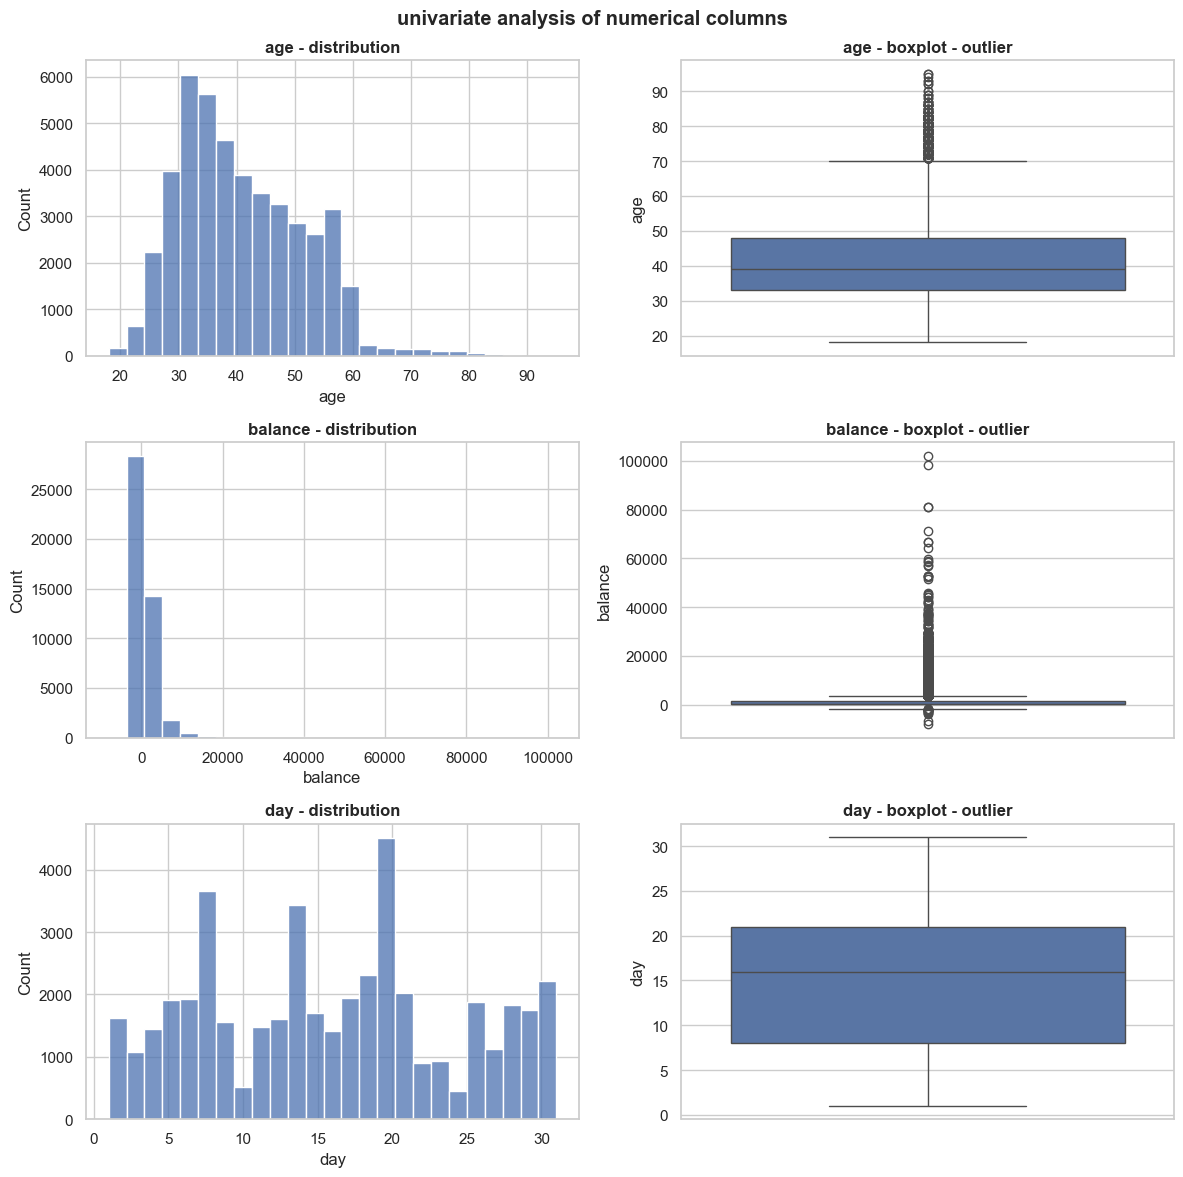

In [7]:
#EDA
#univariate analysis of numerical col
sns.set_theme(style="whitegrid")

num_col_1 = ["age", "balance", "day"]

fig, axes = plt.subplots(3, 2, figsize=(12,12))

for i, col, in enumerate(num_col_1):
    sns.histplot(data=bank, x=col, ax=axes[i][0], bins=25)
    axes[i][0].set_title(f"{col} - distribution", weight='bold')

    sns.boxplot(data=bank, y=col, ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot - outlier", weight='bold')

plt.suptitle("univariate analysis of numerical columns", weight='bold')
plt.tight_layout()
plt.show()

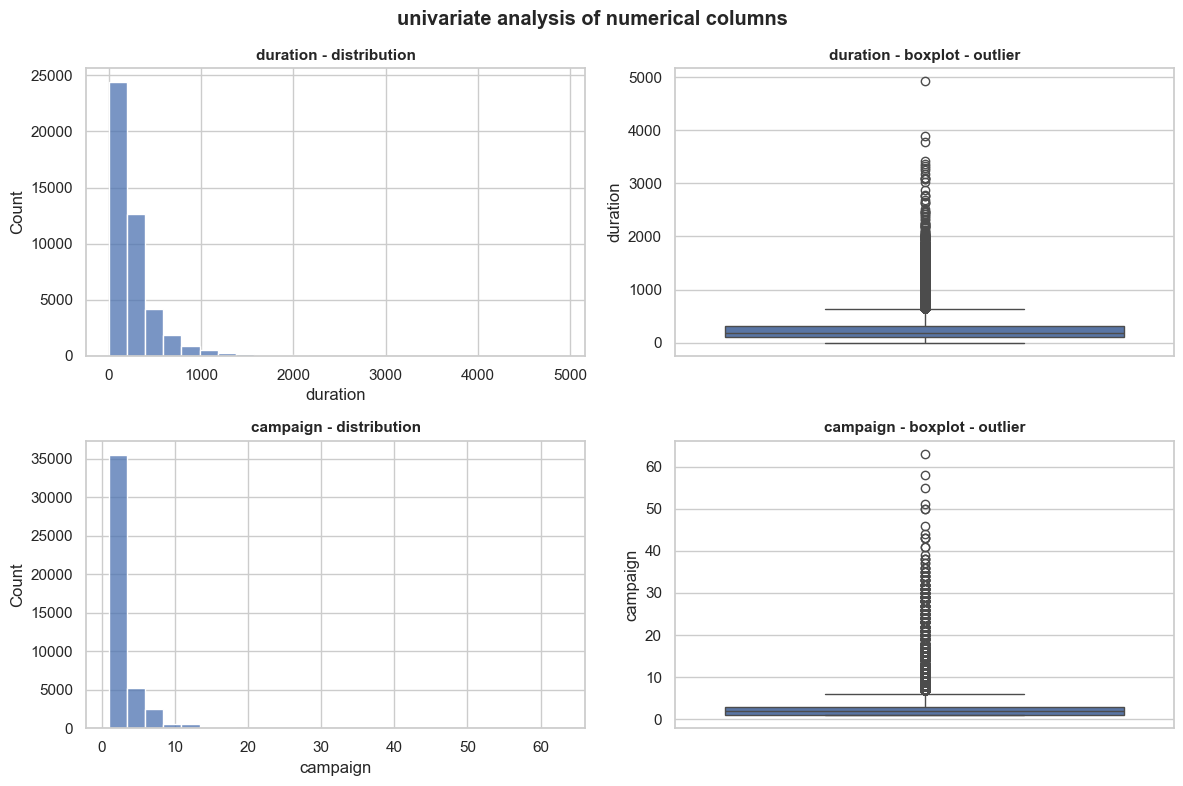

In [8]:
#univariate analysis of numerical col
num_col_2 = ["duration", "campaign"]


fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col, in enumerate(num_col_2):
    sns.histplot(data=bank, x=col, ax=axes[i][0], bins=25)
    axes[i][0].set_title(f"{col} - distribution",fontsize=11, weight='bold')

    sns.boxplot(data=bank, y=col, ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot - outlier", fontsize=11, weight='bold')

plt.suptitle("univariate analysis of numerical columns", weight='bold')
plt.tight_layout()
plt.show()

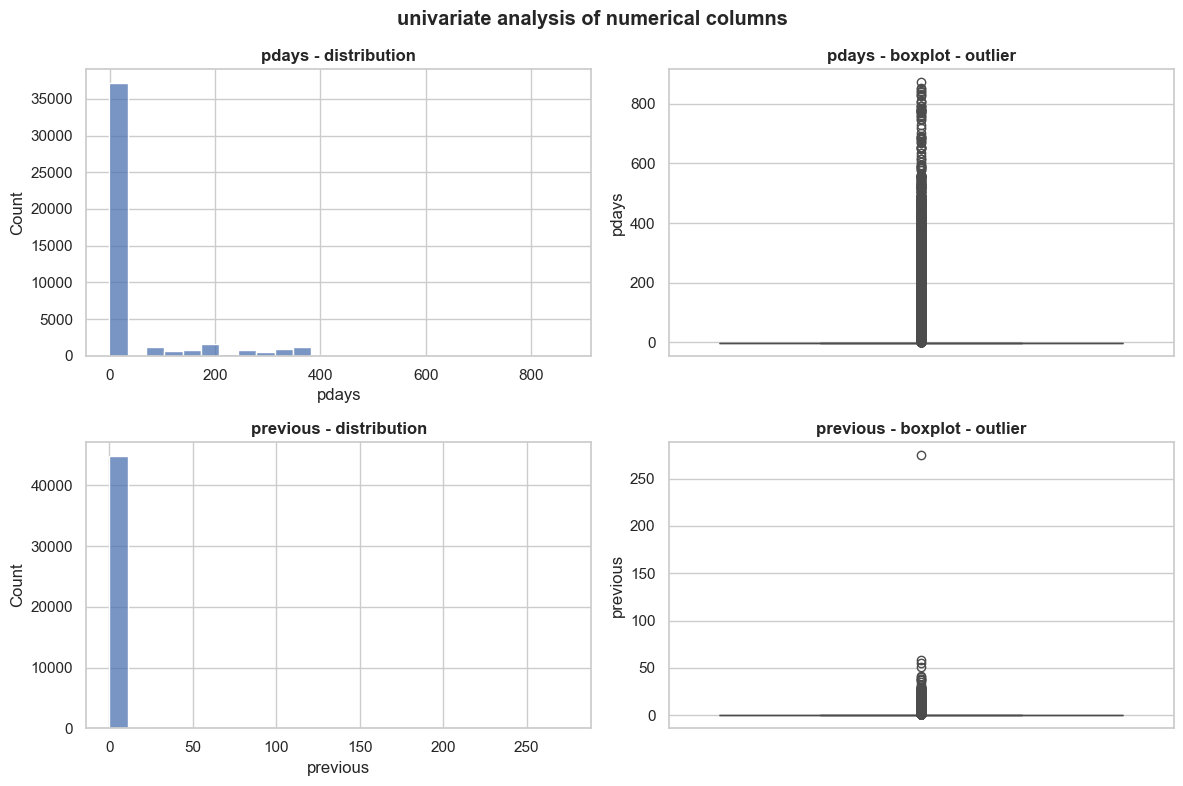

In [9]:
#univariate analysis of numerical col
num_col_3 = ["pdays", "previous"]


fig, axes = plt.subplots(2, 2, figsize=(12,8))

for i, col, in enumerate(num_col_3):
    sns.histplot(data=bank, x=col, ax=axes[i][0], bins=25)
    axes[i][0].set_title(f"{col} - distribution",weight='bold')

    sns.boxplot(data=bank, y=col, ax=axes[i][1])
    axes[i][1].set_title(f"{col} - boxplot - outlier", weight='bold')

plt.suptitle("univariate analysis of numerical columns", weight='bold')
plt.tight_layout()
plt.show()

#### Observation:
 Age distribution shows that most bank customers are between 30 and 45 years old, with few outliers after 70. Balance histogram shows most people have a balance between 0 and 5K, indicating high outliers up to 100K+. Day column looks normal and has no outliers. Duration is highly right-skewed with most calls being very short, but heavy outliers exist between 700 and 3000 seconds. Campaign has a high count at 1, most values 1-7 are in concentrated range, but outliers are stretching upto 63, mean some customer get call again again during the compaign.. Pdays and Previous columns do not show a proper boxplot because the majority of data points are concentrated at -1 and 0 since most customers are new

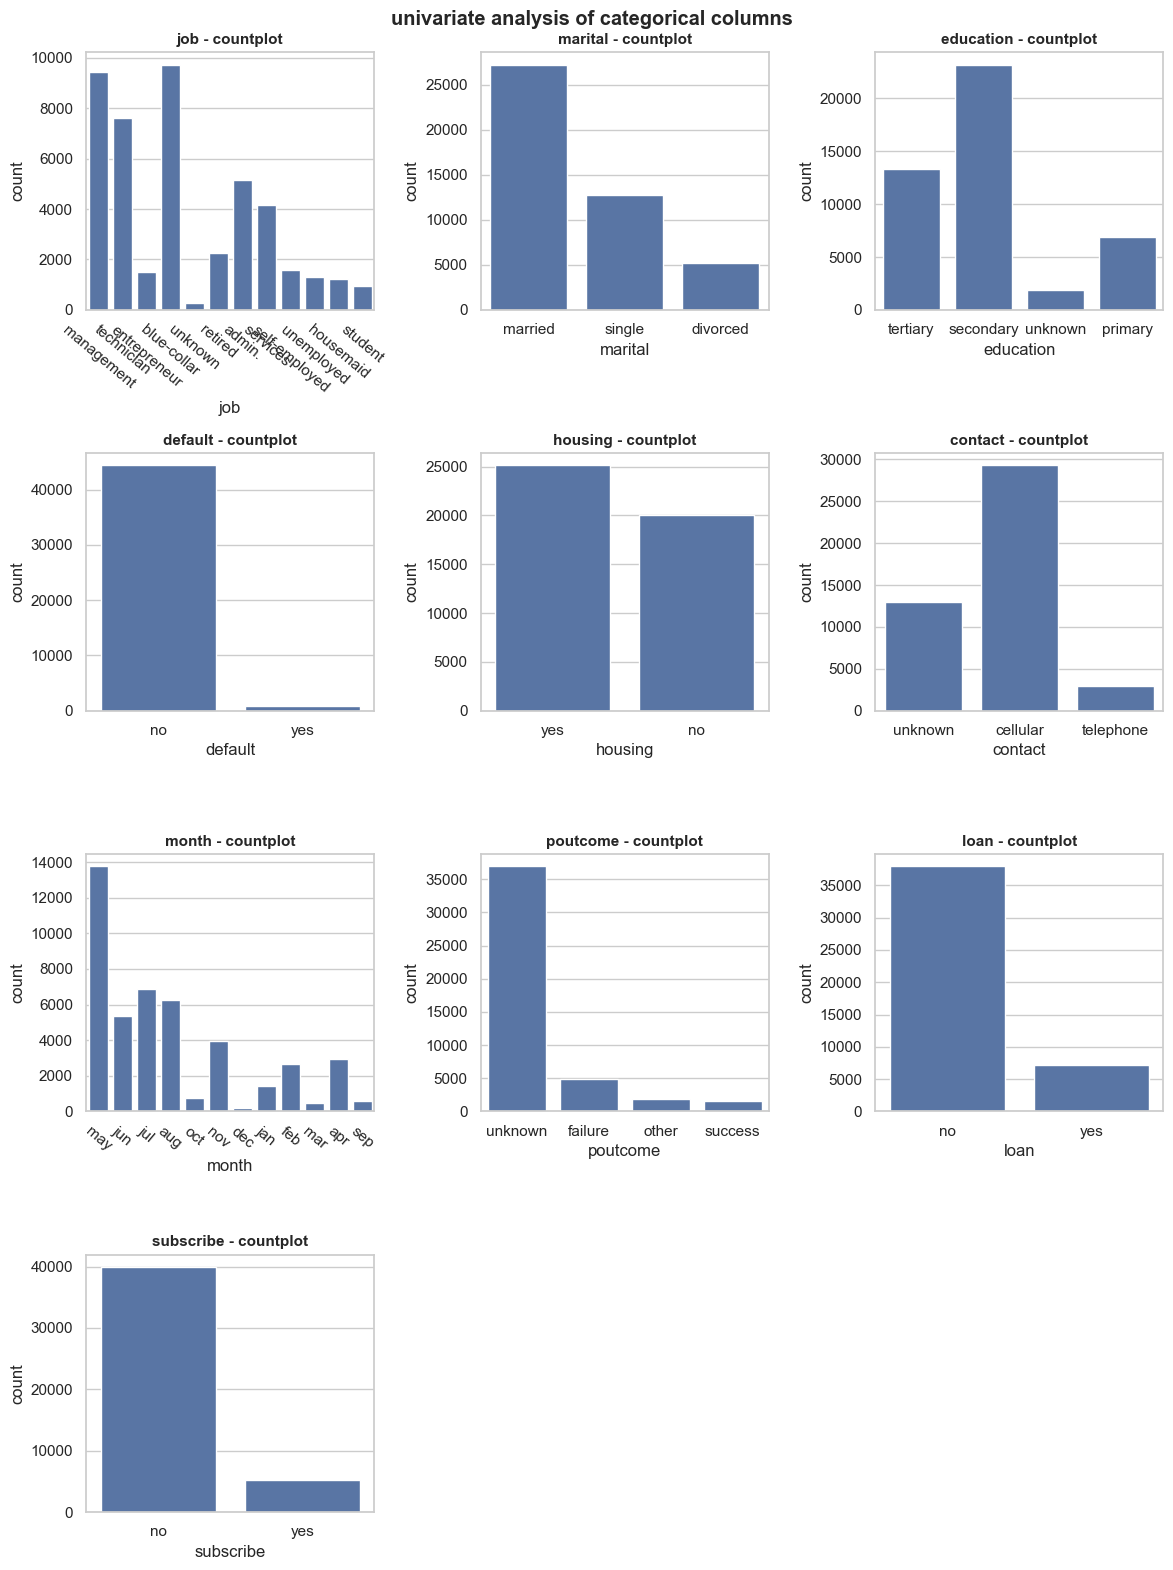

In [10]:
# univariate analysis of categorical columns

cat_col = ["job", "marital", "education", "default", "housing", "contact", "month", "poutcome", "loan", "subscribe"]

fig, axes = plt.subplots(4, 3, figsize=(12,16))
axes = axes.flatten()


for i, col in enumerate(cat_col):
    sns.countplot(data=bank, x=col, ax=axes[i])
    axes[i].set_title(f"{col} - countplot", fontsize=11, weight='bold')
    #adding if condition so that label show clearly
    if col in ["job", "month"]:
        axes[i].tick_params(axis='x', labelrotation=-40)

plt.suptitle("univariate analysis of categorical columns", weight='bold')
plt.tight_layout()
axes[10].set_visible(False)
axes[11].set_visible(False)
plt.show()

#### Observation
Blue collar, management, and technician are the dominant job types in the dataset. Married individuals are the largest group with over 25K counts, followed by singles and then divorcees. Most customers have a secondary education, while tertiary is the second most common. Very few customers have a history of credit default, showing that the bank targets financially stable people. A majority of customers already have a housing loan, but very few have a personal loan. Cellular is the most common communication type, while a significant portion remains unknown. May is the peak month for marketing contacts, while June, July, and August show moderate activity. The previous campaign outcome is mostly unknown, indicating a huge number of new customers. Finally, the target variable y is highly imbalanced as only a small minority subscribe the term deposit

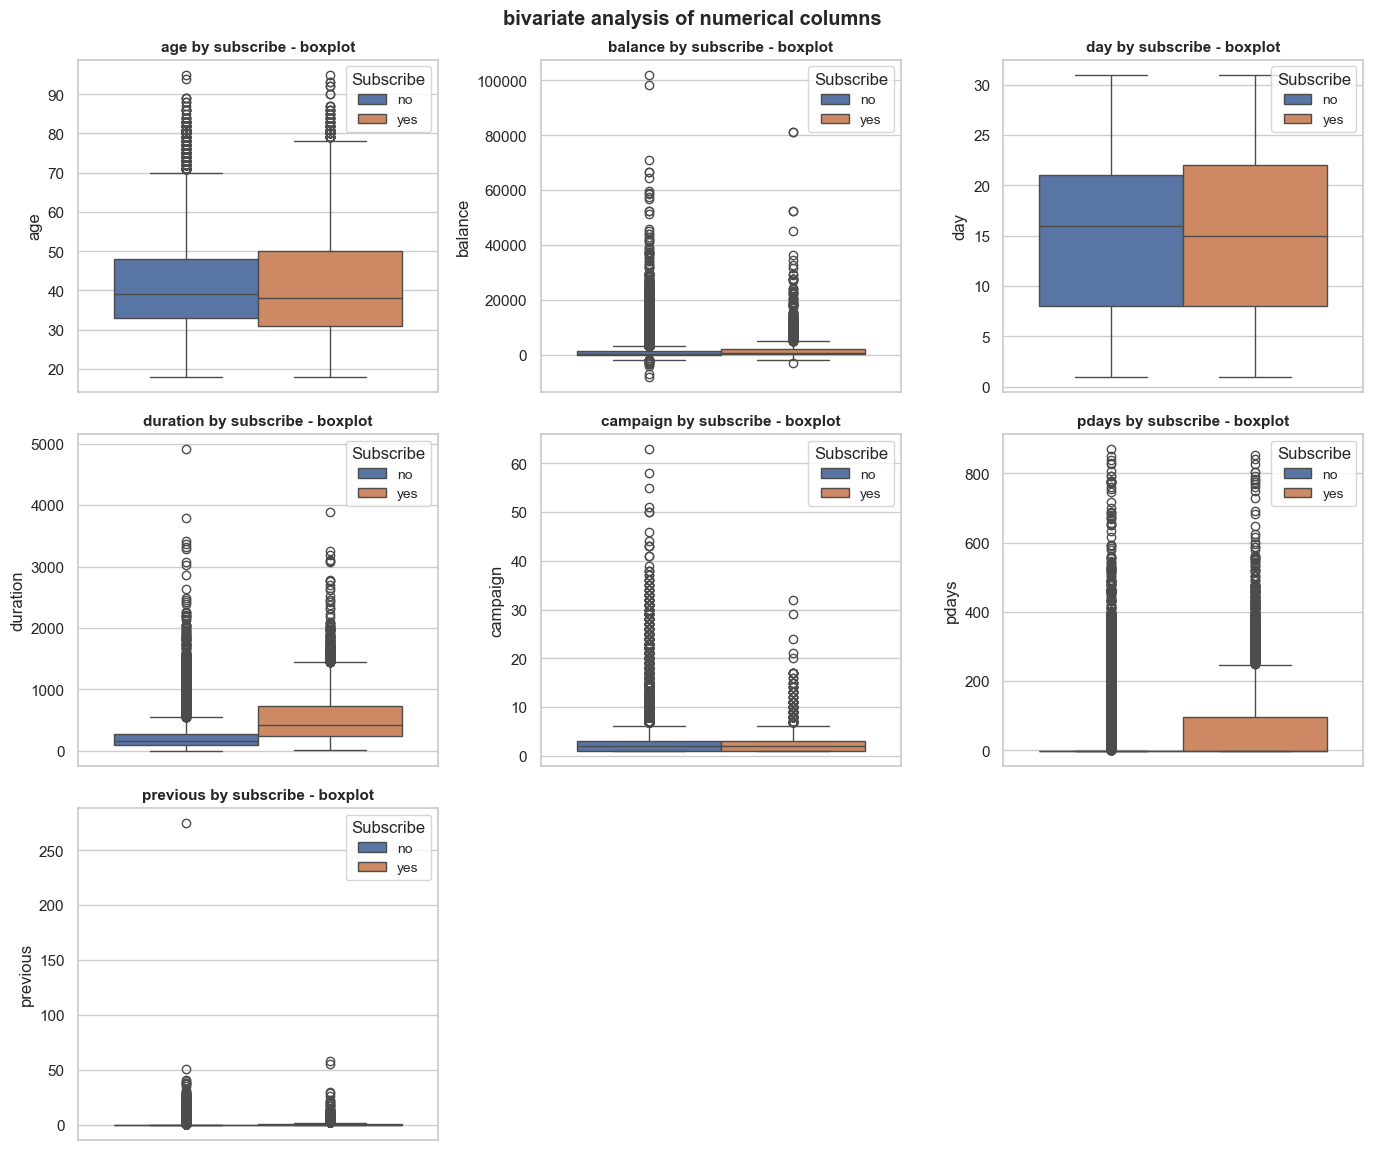

In [11]:
#bivariate analysis of numerical columns

bi_num = ["age", "balance", "day", "duration", "campaign", "pdays", "previous"]

fig, axes = plt.subplots(3, 3, figsize=(14, 12))
axes = axes.flatten()

for i, col in enumerate(bi_num):
    sns.boxplot(data=bank, y=col, hue="subscribe", ax=axes[i])
    axes[i].set_title(f"{col} by subscribe - boxplot", fontsize=11, weight='bold')
    axes[i].legend(loc="upper right", fontsize="small", title="Subscribe")

plt.suptitle("bivariate analysis of numerical columns", weight='bold')
plt.tight_layout()
axes[7].set_visible(False)
axes[8].set_visible(False)
plt.show()

#### Observation
Customers who subscribed tend to have a slightly lower median age but a wider age range. For balance, people with very high account balances generally did not subscribe, while the subscriber group has a slightly higher and more stable median balance. Call duration is the strongest visual factor subscribers had much longer calls, extending up to 1500+ seconds, while non-subscribers had much shorter calls (though duration will be dropped later due to data leakage). For campaign, non-subscribers were called repeatedly with extreme outliers up to 63 times, while subscribers were mostly contacted fewer times. In pdays, the non-subscriber group shows no visible boxplot spread (mostly -1, new customers), while the subscriber group shows contact within a wider range of days  need to verify exact range with .describe() before finalizing the number.

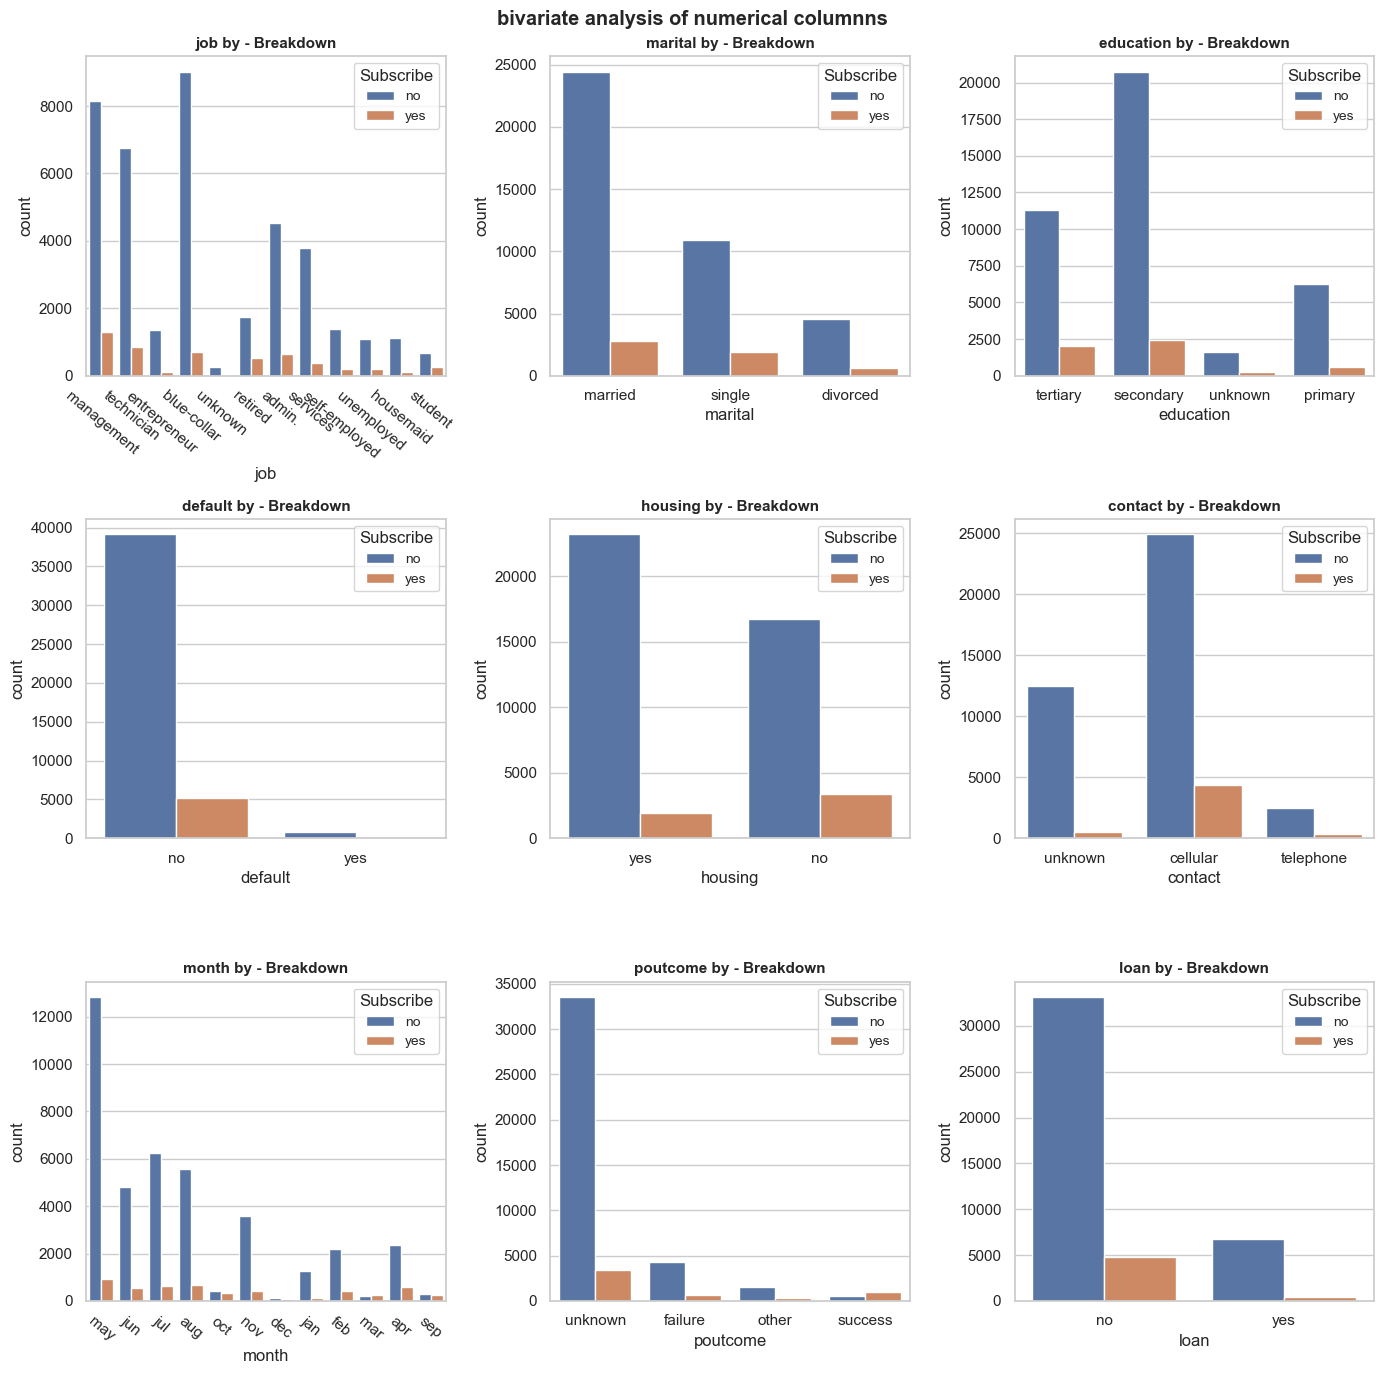

In [ ]:
#Bivariate analysis of numerical columns
bi_cat = ["job", "marital", "education", "default", "housing", "contact", "month", "poutcome", "loan"]


fig, axes = plt.subplots(3, 3, figsize=(14,14))
axes = axes.flatten()

for i, col in enumerate(bi_cat):
    sns.countplot(data=bank, x=col, hue="subscribe", ax=axes[i])
    axes[i].set_title(f"{col} by - Breakdown", fontsize=11, weight='bold')
    axes[i].legend(loc="upper right", fontsize="small", title="Subscribe")
    if col in ["job", "month"]:
        axes[i].tick_params(axis='x', labelrotation=-40)

plt.suptitle("bivariate analysis of numerical columnns", weight='bold')
plt.tight_layout()
plt.show()

#### Observation
 Management, technician, and blue-collar workers have the highest raw counts of subscribers, though their rejection counts are also high (large groups overall). Married individuals form the largest subscriber group, followed by singles. Secondary and tertiary educated individuals are the primary groups saying yes. Customers with no credit default history show more subscribers in raw count — but this may partly reflect that defaulters are a very small group overall (base rate effect), not necessarily lower willingness; proportion analysis needed to confirm. Customers without housing or personal loans show higher subscription volume, suggesting debt-free individuals may be more receptive. Cellular contact brings the highest conversions. May, June, July, and August are peak months for subscribers. Even though poutcome is mostly unknown, the "success" category shows a notably high proportion of subscribers relative to its group size.

In [13]:
percentage_series = bank.groupby('default')['subscribe'].value_counts(normalize=True) * 100
print(percentage_series)

default  subscribe
no       no           88.203892
         yes          11.796108
yes      no           93.619632
         yes           6.380368
Name: proportion, dtype: float64


In [14]:
#  checking default vs subscribe relationship using percentage (not raw count) to avoid base rate bias
percentage_matrix = pd.crosstab(bank['default'], bank['subscribe'], normalize='index') * 100
print(percentage_matrix)

subscribe         no        yes
default                        
no         88.203892  11.796108
yes        93.619632   6.380368


#### Observation 
Non-defaulters have roughly double the subscription rate (11.8%) compared to defaulters (6.4%), confirming that credit default history negatively affects subscription likelihood — not just a base rate artifact.

In [15]:
# checking pdays distribution separately for subscribers vs non-subscribers
bank.groupby('subscribe')['pdays'].describe()

,count,mean,std,min,25%,50%,75%,max
subscribe,,,,,,,,
no,39922.0,36.421372,96.757135,-1.0,-1.0,-1.0,-1.0,871.0
yes,5289.0,68.702968,118.822266,-1.0,-1.0,-1.0,98.0,854.0


#### Observation
For non-subscribers, at least 75% are new customers (pdays = -1, never contacted before); the remaining 25% were contacted before, with contact gap going up to 871 days.
For subscribers, the median is also -1, meaning about half are also new customers who subscribed without prior contact. However, in the top 25% of subscribers who were previously contacted, the gap is 98 days or less (much more recent than non-subscribers), with a max of 854 days. This suggests that recent prior contact increases subscription likelihood, while new customers also convert reasonably well.

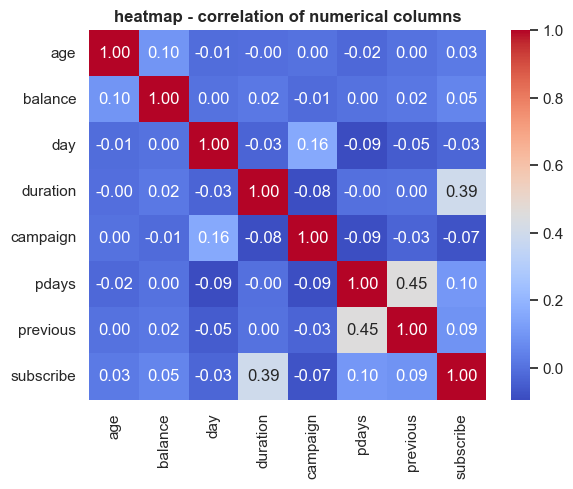

In [16]:
#multivariate analysis using heatmap for numerical col
bank["subscribe"] = bank["subscribe"].str.lower().str.strip()
bank["subscribe"]= bank["subscribe"].map({'yes': 1, 'no': 0}) 
bank_corr = bank.corr(numeric_only=True)
sns.heatmap(data=bank_corr, annot=True, cmap="coolwarm", fmt='.2f')
plt.title("heatmap - correlation of numerical columns", weight='bold')
plt.show()

#### Observation
 Duration has the highest positive correlation of 0.39 with subscribe, proving it is the most important numerical predictor where longer conversations strongly relate to offer acceptance. Both pdays with 0.10 and previous with 0.09 show a mild positive correlation with the target variable, while balance has a very weak relationship of 0.05. A notable internal correlation of 0.45 exists between pdays and previous, suggesting redundant information between these two features. Other pairs like day and campaign show a minor correlation of 0.16 but do not relate significantly to subscribe.

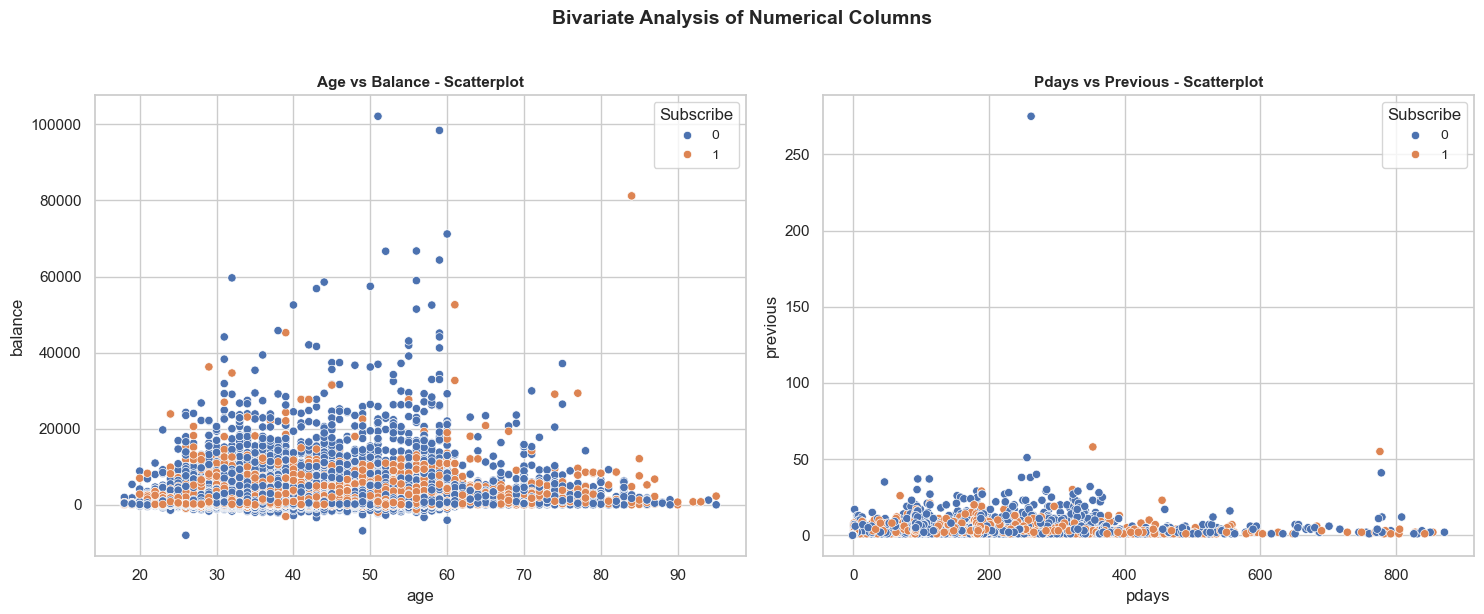

In [17]:
#multivariate analysis of numerical columns with specific col

plot_pairs = [("age", "balance"), ("pdays", "previous")]


fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes = axes.flatten()

for i, (x_col, y_col) in enumerate(plot_pairs):
    sns.scatterplot(data=bank, x=x_col, y=y_col, hue="subscribe", ax=axes[i])
    axes[i].set_title(f"{x_col.capitalize()} vs {y_col.capitalize()} - Scatterplot", fontsize=11, weight='bold')
    axes[i].legend(loc="upper right", fontsize="small", title="Subscribe")

plt.suptitle("Bivariate Analysis of Numerical Columns", weight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

#### Observation
Age and balance combined do not show a clear pattern for subscription. Both subscribers (orange) and non-subscribers (blue) are scattered randomly across the entire chart, with no visible separation or cluster. Higher balance values (up to 100K) mostly appear between ages 25-65, but this doesn't specifically relate to subscription behavior. This confirms age and balance combination is not a strong multivariate predictor.
Similar to age vs balance, pdays vs previous also shows no clear separation between subscribers (orange) and non-subscribers (blue). Most points regardless of subscribe status  are concentrated near pdays=0-200 and previous=0-20, heavily overlapping. A few extreme outliers exist (like previous=275) but they don't show a consistent pattern either. This confirms that pdays and previous combined also don't provide a strong multivariate signal for separating subscribers from non-subscribers.

In [18]:
cat_cols = ["job", "marital", "education", "housing", "loan", "contact", "month", "poutcome", "default"]

for col in cat_cols:
    print('\n', bank.groupby(col)['subscribe'].mean().sort_values(ascending=False) * 100)


 job
student          28.678038
retired          22.791519
unemployed       15.502686
management       13.755551
admin.           12.202669
self-employed    11.842939
unknown          11.805556
technician       11.056996
services          8.883004
housemaid         8.790323
entrepreneur      8.271688
blue-collar       7.274969
Name: subscribe, dtype: float64

 marital
single      14.949179
divorced    11.945458
married     10.123466
Name: subscribe, dtype: float64

 education
tertiary     15.006390
unknown      13.570275
secondary    10.559435
primary       8.626478
Name: subscribe, dtype: float64

 housing
no     16.702355
yes     7.699960
Name: subscribe, dtype: float64

 loan
no     12.655727
yes     6.681391
Name: subscribe, dtype: float64

 contact
cellular     14.918900
telephone    13.420509
unknown       4.070661
Name: subscribe, dtype: float64

 month
mar    51.991614
dec    46.728972
sep    46.459413
oct    43.766938
apr    19.679400
feb    16.647792
aug    11.013286
jun    

#### Observation
Based on correlation analysis (numerical) and percentage-based groupby analysis (categorical), only duration is dropped due to data leakage  the model cannot know call length before making a prediction.
All other columns are kept for model training. Among numerical features, pdays and previous show mild correlation with subscribe (0.10 and 0.09) and are also correlated with each other (0.45), so they will likely be combined into a new feature during feature engineering. balance, age, day, and campaign show very weak linear correlation, but are kept since tree-based models can capture non-linear patterns that correlation doesn't show.
Among categorical features, poutcome (9% to 65% spread) and month (low single digits to 52% spread) are the strongest predictors. job (7% to 29% spread) is also a strong predictor, with students and retired individuals subscribing at notably higher rates. housing and contact show moderate spread (~9-10%), while loan, default, marital, and education show a mild spread (4-6%)  weaker signals, but still kept since none of them are completely flat across categories.

In [19]:
#FEATURE SELECTION & ENGINEERING
from sklearn.preprocessing import StandardScaler, LabelEncoder

FS = bank.copy()
FS.drop(columns=['duration'], inplace=True)

FS['was_contacted_before'] = ((FS['pdays'] != -1) | (FS['previous'] > 0)).astype(int)

#Scaling:

scaler = StandardScaler()
FS["age"]= scaler.fit_transform(FS[["age"]])
FS["balance"] = scaler.fit_transform(FS[["balance"]])
FS["campaign"] = scaler.fit_transform(FS[["campaign"]])
FS["day"] = scaler.fit_transform(FS[["day"]])
FS["pdays"] = scaler.fit_transform(FS[["pdays"]])
FS["previous"] = scaler.fit_transform(FS[["previous"]])

#Label encoding
label = LabelEncoder()
FS["loan"] = label.fit_transform(FS["loan"])
FS["housing"] = label.fit_transform(FS["housing"])
FS["default"] = label.fit_transform(FS["default"])
FS["month"] = label.fit_transform(FS["month"])
FS["education"] = label.fit_transform(FS["education"])

#one hot encoding
FS = pd.get_dummies(data=FS, columns=["marital"], drop_first=True, dtype=int)
FS = pd.get_dummies(data=FS, columns=["contact"], drop_first=True, dtype=int)
FS = pd.get_dummies(data=FS, columns=["poutcome"], drop_first=True, dtype=int)


#we already see that student and retired have % in job for subscribe
high_performers = ['student', 'retired']

FS['job_grouped'] = FS['job'].apply(lambda x: x if x in high_performers else 'other')

#one-hot encode
FS = pd.get_dummies(FS, columns=['job_grouped'], drop_first=True)

# droping original job col
FS.drop(columns=['job'], inplace=True)



In [36]:
print(FS.head())
print(FS.tail())

        age  education  default   balance  housing  loan       day  month  \
0  1.606965          2        0  0.256419        1     0 -1.298476      8   
1  0.288529          1        0 -0.437895        1     0 -1.298476      8   
2 -0.747384          1        0 -0.446762        1     1 -1.298476      8   
3  0.571051          3        0  0.047205        1     0 -1.298476      8   
4 -0.747384          3        0 -0.447091        0     0 -1.298476      8   

   campaign     pdays  ...  was_contacted_before  marital_married  \
0 -0.569351 -0.411453  ...                     0                1   
1 -0.569351 -0.411453  ...                     0                0   
2 -0.569351 -0.411453  ...                     0                1   
3 -0.569351 -0.411453  ...                     0                1   
4 -0.569351 -0.411453  ...                     0                0   

   marital_single  contact_telephone  contact_unknown  poutcome_other  \
0               0                  0             

### LOGISTIC REGRESSION

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_curve ,confusion_matrix
from sklearn.model_selection import train_test_split

model_bank = FS.copy()

X = model_bank.drop(columns="subscribe")
y = model_bank["subscribe"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Training Logistic Regression with balanced weights to handle class imbalance
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)

#predictions on the unseen test set
Bank_test_pred = model.predict(X_test)

#model evaluation
Bank_accuracy = accuracy_score(y_test, Bank_test_pred)
Bank_precision = precision_score(y_test, Bank_test_pred)
Bank_recall= recall_score(y_test, Bank_test_pred)
Bank_cm = confusion_matrix(y_test, Bank_test_pred)
Bank_f1 = f1_score(y_test, Bank_test_pred)
Bank_rc = roc_curve(y_test, Bank_test_pred)

print(f"Bank Accuracy Score = {Bank_accuracy}")
print(f"Bank precision Score = {Bank_precision}")
print(f"Bank recall Score = {Bank_recall}")
print(f"Bank confusion matrix = {Bank_cm}")
print(f"Bank f1 Score = {Bank_f1}")
print(f"Bank roc curve = {Bank_rc}")

Bank Accuracy Score = 0.6908105717129271
Bank precision Score = 0.2289348171701113
Bank recall Score = 0.6599450045829515
Bank confusion matrix = [[5527 2425]
 [ 371  720]]
Bank f1 Score = 0.33994334277620397
Bank roc curve = (array([0.        , 0.30495473, 1.        ]), array([0.      , 0.659945, 1.      ]), array([inf,  1.,  0.]))


### DECISION TREE

In [ ]:
# Initializing, training, and evaluating a Decision Tree model
from sklearn.tree import DecisionTreeClassifier

model2 = DecisionTreeClassifier(class_weight='balanced', max_depth=5, min_samples_leaf=50, random_state=42)

model2.fit(X_train, y_train)
bank_test_pred2 = model2.predict(X_test)

#model evaluation 
bank_accuracy_D = accuracy_score(y_test, bank_test_pred2)
bank_precision_D = precision_score(y_test, bank_test_pred2)
bank_recall_D= recall_score(y_test, bank_test_pred2)
bank_cm_D = confusion_matrix(y_test, bank_test_pred2)
Bank_f1_D = f1_score(y_test, bank_test_pred2)
Bank_rc_D = roc_curve(y_test, bank_test_pred2)

print(f"bank Accuracy Score = {bank_accuracy_D}")
print(f"bank precision Score = {bank_precision_D}")
print(f"bank recall Score = {bank_recall_D}")
print(f"bank confusion matrix = {bank_cm_D}")
print(f"Bank f1 Score = {Bank_f1_D}")
print(f"Bank roc curve = {Bank_rc_D}")

bank Accuracy Score = 0.7296251244056176
bank precision Score = 0.24140565317035906
bank recall Score = 0.5792850595783685
bank confusion matrix = [[5966 1986]
 [ 459  632]]
Bank f1 Score = 0.3407926664869237
Bank roc curve = (array([0.        , 0.24974849, 1.        ]), array([0.        , 0.57928506, 1.        ]), array([inf,  1.,  0.]))


### RANDOM FOREST

In [ ]:
# Initializing, training, and evaluating a Random forest tree model
from sklearn.ensemble import RandomForestClassifier

model_rf = RandomForestClassifier(n_estimators=100, class_weight='balanced_subsample', min_samples_leaf=50, random_state=42)

model_rf.fit(X_train, y_train)
bank_test_pred3 = model_rf.predict(X_test)

# model evaluation performance
bank_accuracy_RF = accuracy_score(y_test, bank_test_pred3)
bank_precision_RF = precision_score(y_test, bank_test_pred3)
bank_recall_RF = recall_score(y_test, bank_test_pred3)
bank_cm_RF = confusion_matrix(y_test, bank_test_pred3)
Bank_f1_RF = f1_score(y_test, bank_test_pred3)
Bank_rc_RF = roc_curve(y_test, bank_test_pred3)


print(f"bank Accuracy Score = {bank_accuracy_RF}")
print(f"bank precision Score = {bank_precision_RF}")
print(f"bank recall Score = {bank_recall_RF}")
print(f"bank confusion matrix = {bank_cm_RF}")
print(f"Bank f1 Score = {Bank_f1_RF}")
print(f"Bank roc curve = {Bank_rc_RF}")

bank Accuracy Score = 0.7933208006192635
bank precision Score = 0.3142311365807068
bank recall Score = 0.6031164069660861
bank confusion matrix = [[6516 1436]
 [ 433  658]]
Bank f1 Score = 0.41318681318681316
Bank roc curve = (array([0.       , 0.1805835, 1.       ]), array([0.        , 0.60311641, 1.        ]), array([inf,  1.,  0.]))


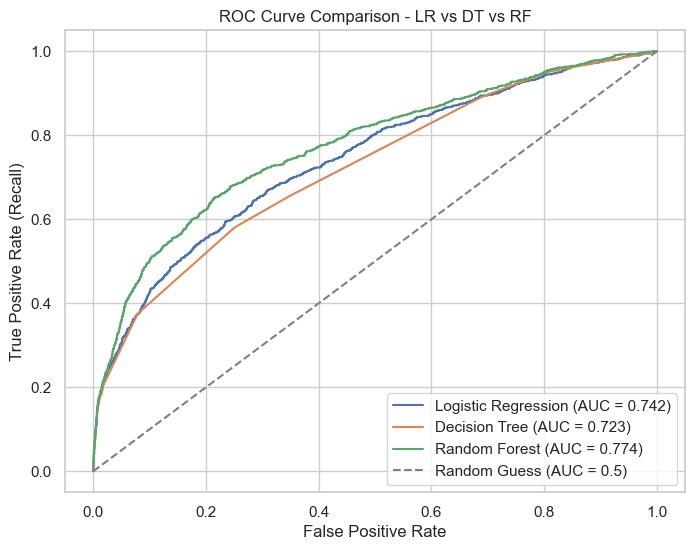

In [28]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Getting probability scores (not direct predictions) for ROC curve
# ROC needs probabilities to check performance across ALL thresholds
prob_lr = model.predict_proba(X_test)[:, 1]
prob_dt = model2.predict_proba(X_test)[:, 1]
prob_rf = model_rf.predict_proba(X_test)[:, 1]

# Calculating FPR, TPR for each model
fpr_lr, tpr_lr, _ = roc_curve(y_test, prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, prob_dt)
fpr_rf, tpr_rf, _ = roc_curve(y_test, prob_rf)

# Calculating AUC score for each model
auc_lr = roc_auc_score(y_test, prob_lr)
auc_dt = roc_auc_score(y_test, prob_dt)
auc_rf = roc_auc_score(y_test, prob_rf)

# Plotting
plt.figure(figsize=(8,6))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC = {auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC = {auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")
plt.plot([0,1], [0,1], linestyle='--', color='gray', label="Random Guess (AUC = 0.5)")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve Comparison - LR vs DT vs RF")
plt.legend()
plt.show()

#### Observation
We trained three classification models: Logistic Regression, Decision Tree, and Random Forest. At the default threshold (0.5), Logistic Regression had the highest recall (66.0%), but its precision and accuracy were the lowest among the three. Random Forest had a lower recall (59.9%) at this threshold, but significantly better precision (28.2%) and accuracy (76.8%).
To get a fairer overall comparison, we used ROC Curve and AUC score, which evaluate model performance across all possible thresholds not just 0.5. This revealed that Random Forest is actually the strongest model overall (AUC = 0.774), compared to Logistic Regression and Decision Tree (both AUC = 0.723). Random Forest also had the best F1-Score (0.413), showing the best balance between precision and recall.
Since our business goal prioritizes recall (missing an actual subscriber is more costly than a wasted call), we selected Random Forest as our final model. Its higher AUC means it has stronger potential to achieve better recall than Logistic Regression once we tune the classification threshold in the Improvement stage while keeping false positives more controlled.

In [29]:
import shap

#creating ashape for over trained rf model
explainer = shap.TreeExplainer(model_rf)

#calc shap value for test data
shap_values = explainer.shap_values(X_test)

In [32]:
import numpy as np
print(type(shap_values))
print(np.array(shap_values).shape)

<class 'numpy.ndarray'>
(9043, 21, 2)


In [ ]:
# Taking only class 1 (subscribe = yes) SHAP values
shap_values_class1 = shap_values[:, :, 1]

print(shap_values_class1.shape) 

(9043, 21)


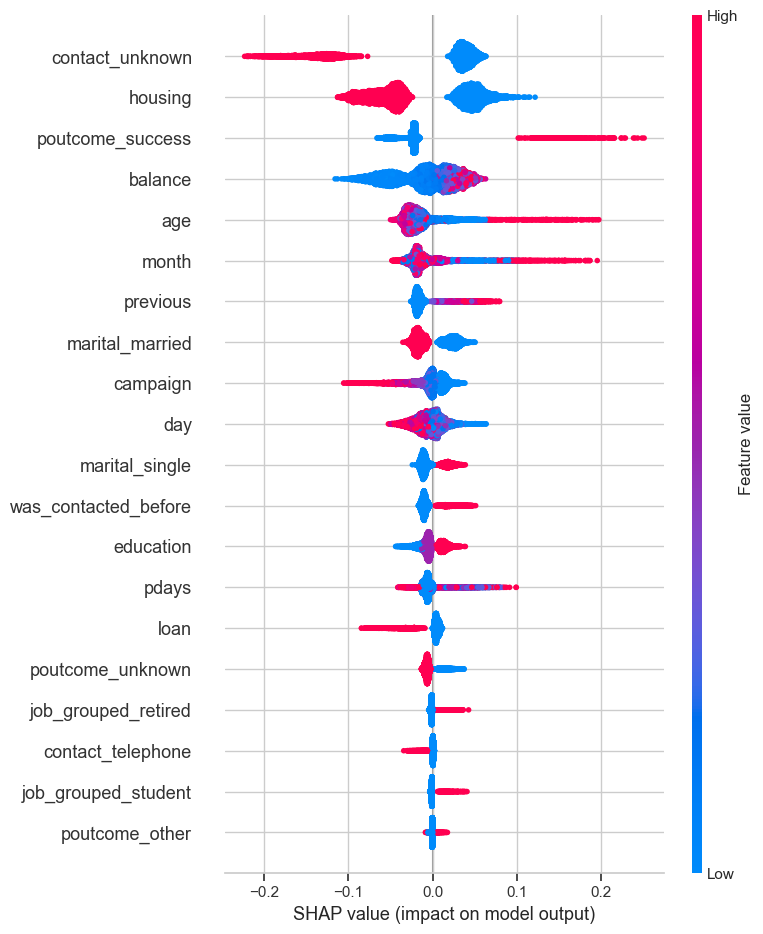

In [34]:
shap.summary_plot(shap_values_class1, X_test, feature_names=X_test.columns)

### SHAP Model Interpretability Observations:
poutcome_success (Highest Positive Impact): Customers who successfully subscribed in the past campaign (High/Red values) have the strongest positive impact on predicting a new subscription.<br>
contact_unknown & housing (Negative Impact): If the contact communication type is unknown or if the customer already has a housing loan (High/Red values), it strongly pushes the model to predict "No" subscription.<br>
age & month: Higher age and specific campaign months (High/Red values) show a strong positive impact, meaning older customers and better timing increase subscription chances.<br>
balance: Higher account balances positively influence the model's prediction toward a "Yes" subscription.


--- Customer 0 ---
Actual label: 0
Predicted probability (yes): 0.223


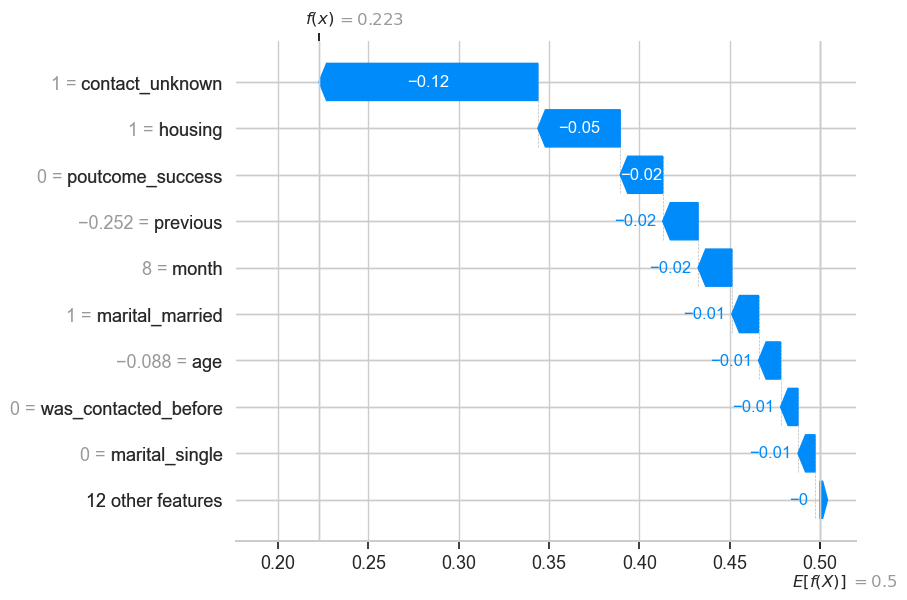


--- Customer 1 ---
Actual label: 0
Predicted probability (yes): 0.345


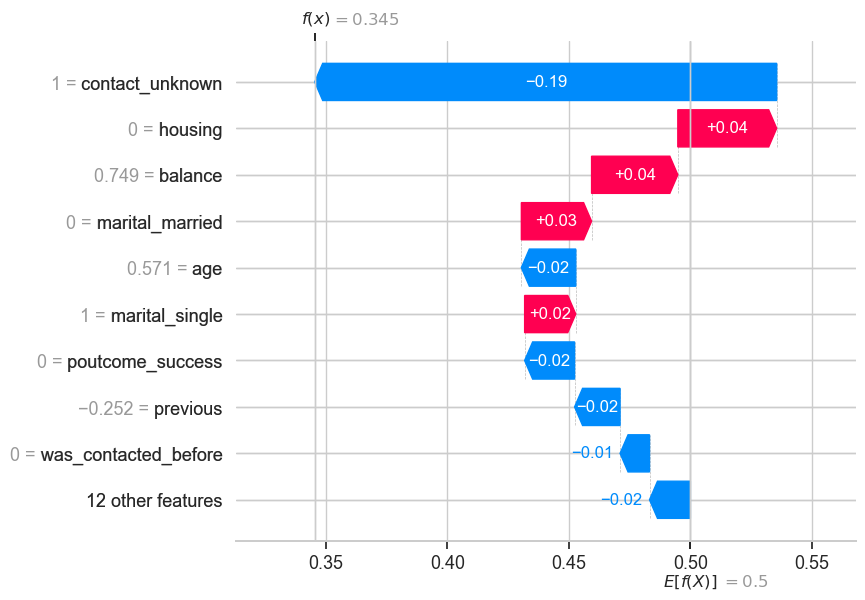


--- Customer 2 ---
Actual label: 0
Predicted probability (yes): 0.570


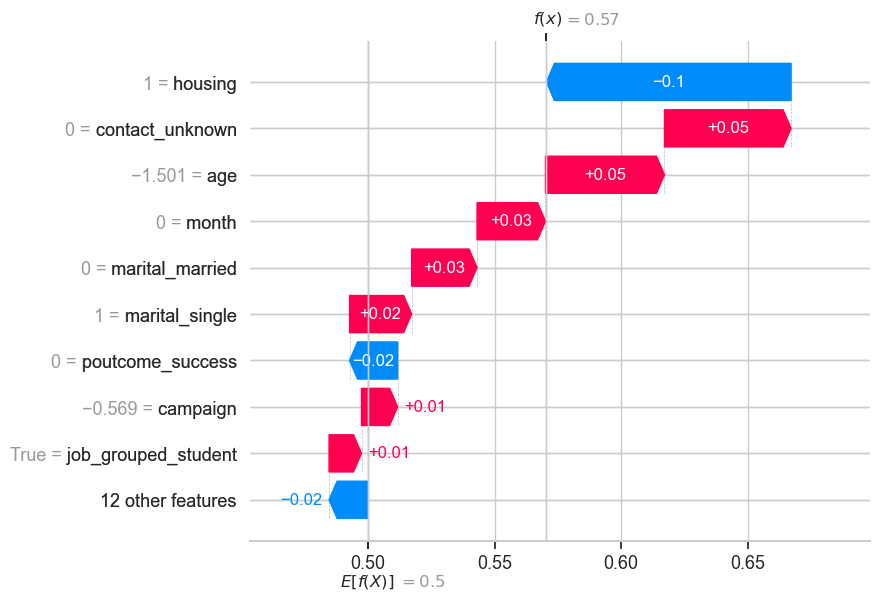


--- Customer 3 ---
Actual label: 0
Predicted probability (yes): 0.678


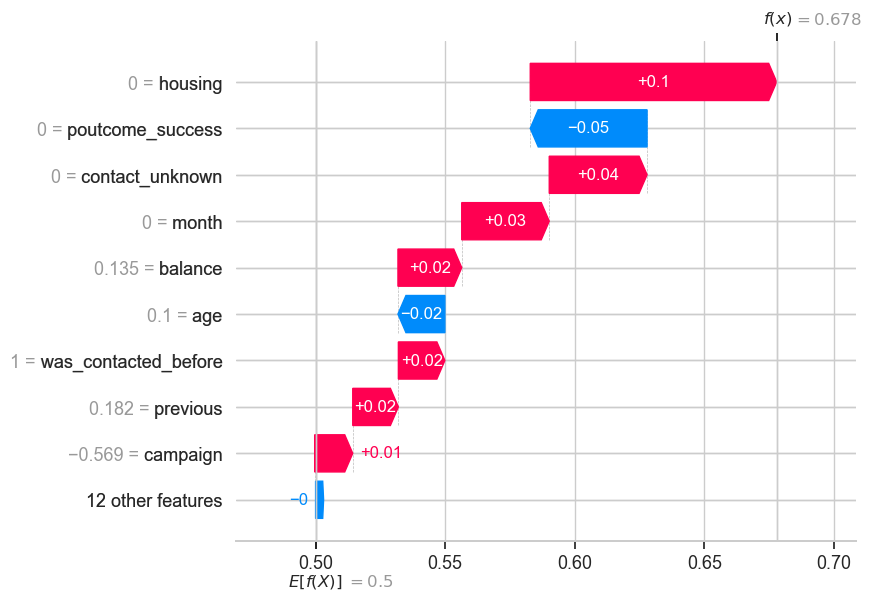


--- Customer 4 ---
Actual label: 0
Predicted probability (yes): 0.286


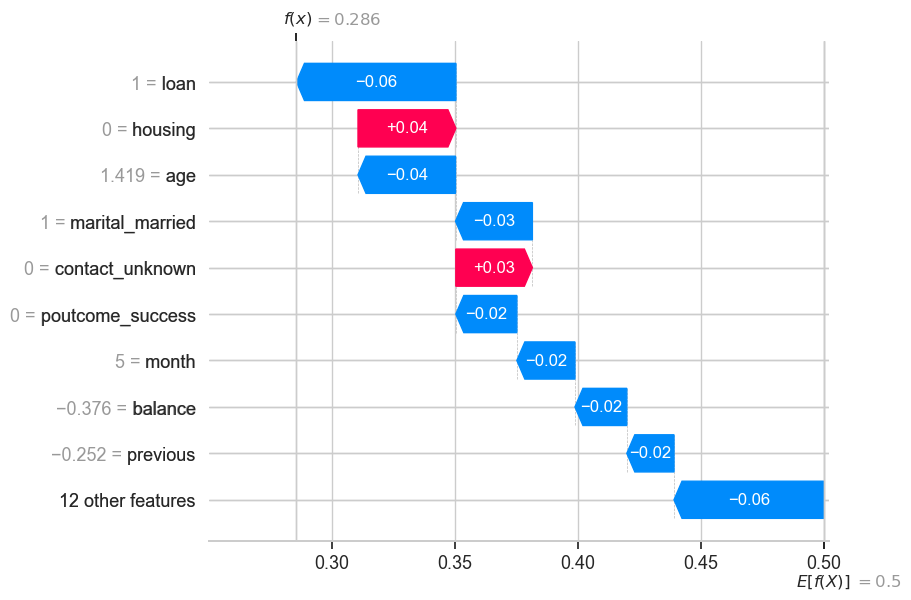

In [ ]:
# Pick 5 random customers from test set to explain
sample_indices = [0, 1, 2, 3, 4] 

for i in sample_indices:
    print(f"\n--- Customer {i} ---")
    print(f"Actual label: {y_test.iloc[i]}")
    print(f"Predicted probability (yes): {model_rf.predict_proba(X_test)[i][1]:.3f}")
    
    shap.plots.waterfall(shap.Explanation(
        values=shap_values_class1[i], 
        base_values=explainer.expected_value[1], 
        data=X_test.iloc[i], 
        feature_names=X_test.columns.tolist()
    ))

#### Individual Customer Prediction Explanations (SHAP Waterfall Plots)
* Customer 0 (Low Subscription Probability: 22.3%)

Observation: The model predicted a very low chance of subscription. The biggest negative drivers were contact_unknown = 1 (-0.12) and housing = 1 (-0.05). Having an unknown contact method and an active housing loan strongly dragged the probability down from the base value.

* Customer 1 (Low Subscription Probability: 34.5%)

Observation: Even though this customer had positive push factors like a healthy account balance = 0.749 (+0.04) and no housing loan (housing = 0 (+0.04)), the single largest negative factor was contact_unknown = 1 (-0.19), which heavily dropped the final score to 34.5%.

* Customer 2 (Medium-High Subscription Probability: 57.0%)

Observation: The model crosses the baseline threshold here. The main reason for this positive prediction (Yes) is that the customer does not have an unknown communication channel (contact_unknown = 0 (+0.05)) and has a younger or highly favorable age index (age = -1.501 (+0.05)), overcoming the negative impact of having a housing loan.

* Customer 3 (Highest Subscription Probability: 67.8%)

Observation: This customer is highly likely to subscribe. The major positive driver is housing = 0 (+0.10), meaning the absence of a housing loan gives them a massive push toward subscribing to a term deposit. Additional small positive values from balance and contact_unknown pushed it further up to 67.8%.

* Customer 4 (Low Subscription Probability: 28.6%)

Observation: This customer is highly unlikely to subscribe. The primary reason is that they already have a personal loan active (loan = 1 (-0.06)), combined with being married (marital_married = 1 (-0.03)) and having a negative balance shift (balance = -0.376 (-0.02)). These factors heavily decreased the final model output.

### Conclusion:
Dataset: UCI Bank Marketing (bank-full.csv, 45,211 rows, 17 columns), target = y (renamed subscribe)
Workflow Completed:

* Problem Definition: Classification; Recall (class 1) chosen as primary metric since missing an actual subscriber (False Negative) is costlier than a wasted call (False Positive)<br>
* Data Understanding: No nulls/duplicates, but "unknown" values act as hidden missing data; pdays=-1 and poutcome=unknown both indicate "never contacted before"<br>

* EDA:  Univariate, Bivariate (discovered base-rate bias issue with default, verified pdays percentiles properly), Multivariate (heatmap + scatter plots — no strong numerical combinations found)<br>
* Feature Selection : Only duration dropped (data leakage); all other features kept due to at least mild signal <br>
* Feature Engineering:  Created was_contacted_before flag (combining pdays + previous), scaled numerical features, label-encoded ordinal/binary features, one-hot encoded nominal features, grouped rare job categories<br>
* Model Training : Logistic Regression, Decision Tree, Random Forest trained<br>
* Evaluation :  Confusion Matrix, F1-Score, ROC-AUC compared; Random Forest selected as best model (AUC=0.774, F1=0.413), despite Logistic Regression having higher raw recall at default threshold<br>
* SHAP Explainability :  Used TreeExplainer on Random Forest; Summary plot showed contact_unknown, housing, and poutcome_success as top global drivers; explained 5 individual customer predictions via waterfall plots, confirming contact_unknown as a recurring dominant factor<br>